<a href="https://colab.research.google.com/github/ahirwarsuresh062-web/Decision-Tree/blob/main/Decision_Tree_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Decision Tree Assignment

Part A: Theory Questions

Q1. What is a Decision Tree, and how does it work?

Ans. A Decision Tree is a supervised machine learning algorithm used for classification and regression. It works like a flowchart where:

Each internal node represents a feature

Each branch represents a decision rule

Each leaf node represents an output (class label or value)

The tree splits the data step by step based on feature values to reach a final decision.

Q2. What are impurity measures in Decision Trees?

Ans. Impurity measures tell us how mixed the data is at a node. They help decide the best feature to split the data. Common impurity measures are:

Gini Impurity

Entropy

Q3. Mathematical formula for Gini Impurity

Ans. Gini Impurity is calculated as:

Gini = 1 − Σ (pi)²

Where pi is the probability of class i.

Q4. Mathematical formula for Entropy

Ans. Entropy is calculated as:

Entropy = − Σ pi log₂(pi)

Where pi is the probability of class i.

Q5. What is Information Gain?

Ans. Information Gain measures the reduction in entropy after a dataset is split. The feature with the highest information gain is chosen for splitting.

Information Gain = Entropy(parent) − Weighted Entropy(children)

Q6. Difference between Gini Impurity and Entropy

Ans. Gini Impurity	Entropy
Faster to compute	Slower
Used by CART	Used by ID3
Less sensitive to small changes	More sensitive

Q7. Mathematical explanation behind Decision Trees

Ans. Decision Trees use greedy algorithms to minimize impurity at each split. At each node, the algorithm evaluates all possible splits and chooses the one that results in maximum information gain or minimum impurity.

Q8. What is Pre-Pruning?

Ans. Pre-pruning stops the tree from growing too large by setting limits like max depth, minimum samples per split, etc.

Q9. What is Post-Pruning?

Ans. Post-pruning allows the tree to grow fully and then removes branches that do not improve performance.

Q10. Difference between Pre-Pruning and Post-Pruning

Ans. Pre-Pruning	Post-Pruning
Stops early	Cuts later
Faster	More accurate
Less complex	More computation

Q11. What is a Decision Tree Regressor?

Ans. It is a Decision Tree used for predicting continuous values instead of class labels.

Q12. Advantages and Disadvantages of Decision Trees

Ans. Advantages:

Easy to understand

No feature scaling required

Handles non-linear data

Disadvantages:

Overfitting

Sensitive to noise

Q13. Handling missing values

Ans. Decision Trees can handle missing values by:

Using surrogate splits

Replacing missing values with mean/mode

Q14. Handling categorical features

Ans. Categorical features are handled by:

Label Encoding

One-Hot Encoding

Q15. Real-world applications

Ans. Medical diagnosis

Credit risk analysis

Fraud detection

Customer segmentation

#Part-B Practical Questions

In [ ]:
#Ans1. Decision Tree Classifier on Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


model = DecisionTreeClassifier()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [ ]:
#Ans2. Decision Tree using Gini Impurity
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)
print("Feature Importances:", model.feature_importances_)

Feature Importances: [0.02336213 0.02928258 0.54041087 0.40694442]


In [ ]:
#Ans3. Decision Tree using Entropy
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9666666666666667


In [ ]:
#Ans4. Decision Tree Regressor (Housing dataset)
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)


pred = reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred))

MSE: 0.5394901408038275


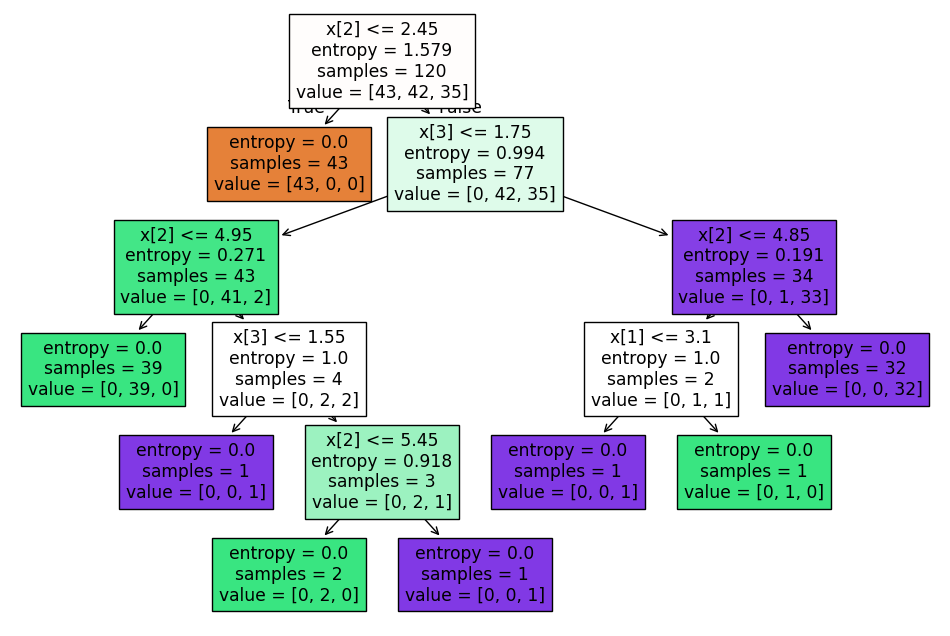

In [ ]:
#Ans5.Visualizing Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

In [ ]:
#Ans6.Max Depth Comparison
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor

model_depth3 = DecisionTreeRegressor(max_depth=3) # Changed to Regressor
model_depth3.fit(X_train, y_train)
# For regressors, we typically evaluate with MSE or R2, not accuracy_score
from sklearn.metrics import mean_squared_error
print("Depth 3 MSE:", mean_squared_error(y_test, model_depth3.predict(X_test)))

Depth 3 MSE: 0.6581519532800407


In [ ]:
#Ans7.min_samples_split Comparison
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error # Import mean_squared_error for regression evaluation

model_split = DecisionTreeRegressor(min_samples_split=5)
model_split.fit(X_train, y_train)
print("MSE:", mean_squared_error(y_test, model_split.predict(X_test)))

MSE: 0.5326699762585404


In [ ]:
#Ans8 Feature Scaling Comparison
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Ans9 One-vs-Rest Strategy
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Reload Iris data for classification task
X_iris, y_iris = load_iris(return_X_y=True)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

ovr = OneVsRestClassifier(DecisionTreeClassifier())
ovr.fit(X_train_iris, y_train_iris)

# Optional: Evaluate the model
from sklearn.metrics import accuracy_score
y_pred_iris = ovr.predict(X_test_iris)
print("Accuracy with OneVsRestClassifier on Iris dataset:", accuracy_score(y_test_iris, y_pred_iris))

Accuracy with OneVsRestClassifier on Iris dataset: 1.0


In [ ]:
#Ans10. Feature Importance
print(model.feature_importances_)

[0.         0.01055435 0.67488918 0.31455646]


In [ ]:
#Ans11.Regressor max_depth=5 Comparison
reg_depth5 = DecisionTreeRegressor(max_depth=5)
reg_depth5.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [ ]:
#Ans12. Cost Complexity Pruning
# The previous 'model' variable was a DecisionTreeClassifier, which expects discrete classes.
# X_train and y_train here are from the housing dataset, which is a regression problem with continuous values.
# We should use a DecisionTreeRegressor that has been fitted to the regression data.
# 'reg_depth5' from Ans11 is a suitable regressor.
path = reg_depth5.cost_complexity_pruning_path(X_train, y_train)
print(path.ccp_alphas)

[0.         0.00060698 0.00095317 0.00101084 0.00197545 0.00209238
 0.00221669 0.00229643 0.00242116 0.00264165 0.0032513  0.00389976
 0.00406066 0.00418942 0.0043368  0.00537797 0.00646779 0.0065178
 0.00705412 0.00819492 0.00949172 0.01030981 0.01074209 0.0110031
 0.01293282 0.01608337 0.01960604 0.02433868 0.05885741 0.07564678
 0.1086526  0.4146337 ]


In [ ]:
#Ans13 Precision, Recall, F1-Score
from sklearn.metrics import classification_report
print(classification_report(y_test_iris, y_pred_iris))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



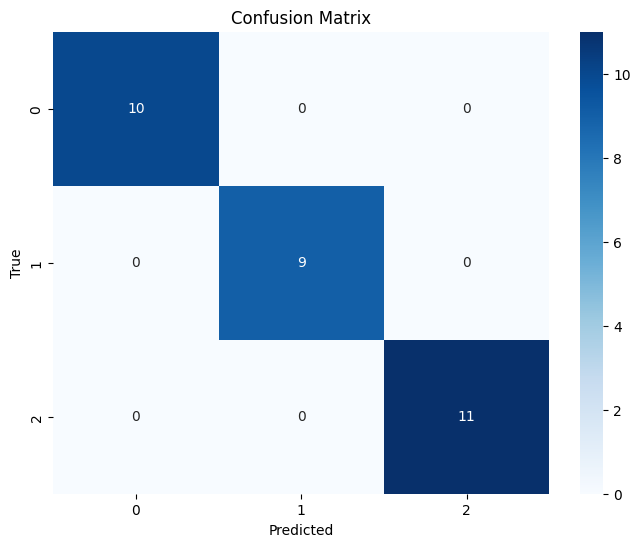

In [ ]:
#Ans14. Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Start of fix: ensure y_test_iris and y_pred_iris are defined ---
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Reload Iris data for classification task
X_iris, y_iris = load_iris(return_X_y=True)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

ovr = OneVsRestClassifier(DecisionTreeClassifier())
ovr.fit(X_train_iris, y_train_iris)

y_pred_iris = ovr.predict(X_test_iris)
# --- End of fix ---


cm = confusion_matrix(y_test_iris, y_pred_iris)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()